# Benchmark Figures — D-U-S vs D-U-S-D vs D-U-S-M

Reads the four result CSVs from `../experiments/experiment_results_dus/` and saves one publication-quality PNG per benchmark.  
Error bands show ± 1 standard deviation across repetitions.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = '../experiments/experiment_results_dus'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         13,
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'legend.fontsize':   12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
})

COLORS  = {'D-U-S': '#dd6108', 'D-U-S-D': '#ffc107', 'D-U-S-M': '#4c72b0'}
MARKERS = {'D-U-S': 'o',       'D-U-S-D': 's',       'D-U-S-M': '^'}


def plot_benchmark(csv_file, x_col, xlabel, title, out_name, x_divisor=1):
    """Plot mean ± std runtime per algorithm and save as PNG.

    x_divisor: divide x values before plotting (e.g. 1000 to show thousands).
    """
    df = pd.read_csv(os.path.join(RESULTS_DIR, csv_file))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for alg, grp in df.groupby('algorithm'):
        stats = grp.groupby(x_col)['time_s'].agg(['mean', 'std']).reset_index()
        x = stats[x_col] / x_divisor
        ax.plot(x, stats['mean'],
                marker=MARKERS[alg], color=COLORS[alg],
                linewidth=1.8, markersize=5, label=alg)
        ax.fill_between(x,
                         (stats['mean'] - stats['std']).clip(lower=0),
                         stats['mean'] + stats['std'],
                         alpha=0.15, color=COLORS[alg])

    ax.set_xlabel(xlabel)
    ax.set_ylabel('mean runtime (s)')
    ax.set_title(title)
    ax.legend(framealpha=0.9)

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, out_name)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')

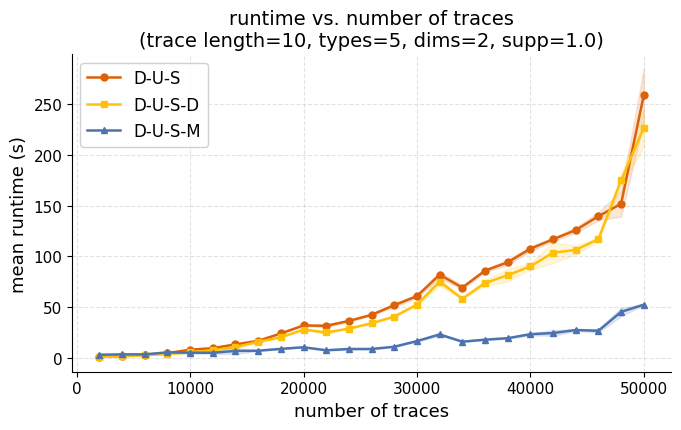

Saved → ../experiments/experiment_results_dus/fig_trace_count.png


In [2]:
plot_benchmark(
    csv_file  = 'dus_trace_count.csv',
    x_col     = 'trace_count',
    xlabel    = 'number of traces',
    title     = 'runtime vs. number of traces\n(trace length=10, types=5, dims=2, supp=1.0)',
    out_name  = 'fig_trace_count.png',
)

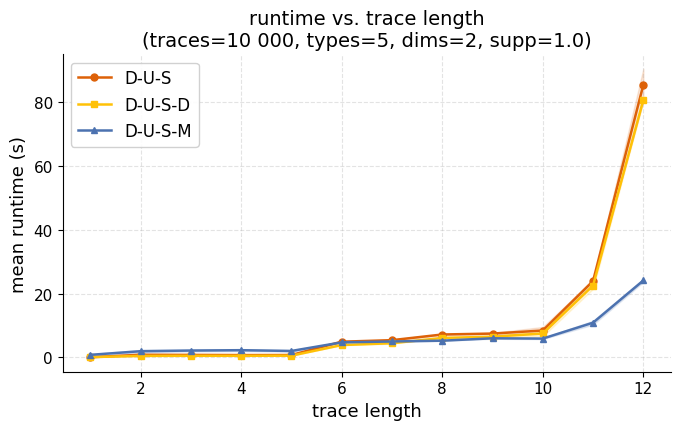

Saved → ../experiments/experiment_results_dus/fig_trace_length.png


In [3]:
plot_benchmark(
    csv_file  = 'benchmark_dus_trace_length.csv',
    x_col     = 'trace_length',
    xlabel    = 'trace length',
    title     = 'runtime vs. trace length\n(traces=10 000, types=5, dims=2, supp=1.0)',
    out_name  = 'fig_trace_length.png',
)

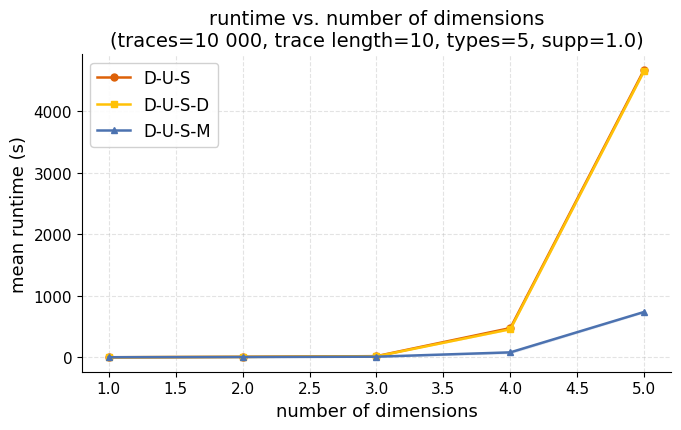

Saved → ../experiments/experiment_results_dus/fig_dimensions.png


In [4]:
plot_benchmark(
    csv_file  = 'benchmark_dus_dimensions.csv',
    x_col     = 'dimensions',
    xlabel    = 'number of dimensions',
    title     = 'runtime vs. number of dimensions\n(traces=10 000, trace length=10, types=5, supp=1.0)',
    out_name  = 'fig_dimensions.png',
)

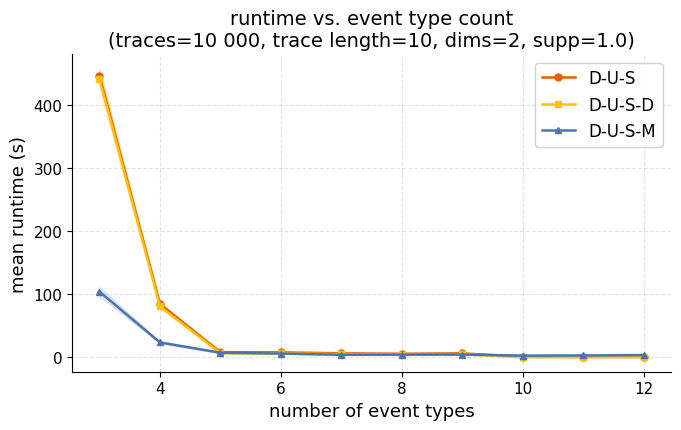

Saved → ../experiments/experiment_results_dus/fig_type_count.png


In [5]:
plot_benchmark(
    csv_file  = 'benchmark_dus_type_count.csv',
    x_col     = 'type_count',
    xlabel    = 'number of event types',
    title     = 'runtime vs. event type count\n(traces=10 000, trace length=10, dims=2, supp=1.0)',
    out_name  = 'fig_type_count.png',
)

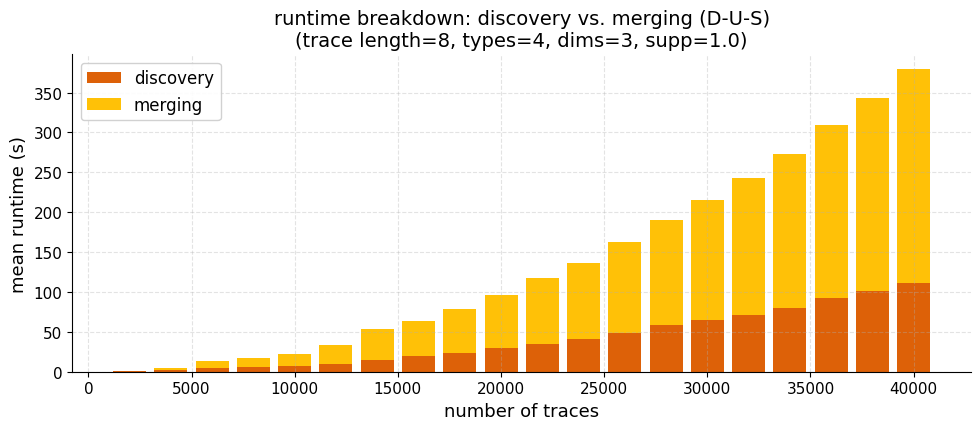

Saved → ../experiments/experiment_results_dus/fig_dus_stacked.png


In [11]:
df_stack = pd.read_csv(os.path.join(RESULTS_DIR, 'dus_results_param3.csv'))

fig, ax = plt.subplots(figsize=(10, 4.5))

bar_width = 1600
ax.bar(df_stack['n'], df_stack['discovery_s'], width=bar_width,
       color='#dd6108', label='discovery')
ax.bar(df_stack['n'], df_stack['merging_s'], width=bar_width,
       bottom=df_stack['discovery_s'], color='#ffc107', label='merging')

ax.set_xlabel('number of traces')
ax.set_ylabel('mean runtime (s)')
ax.set_title('runtime breakdown: discovery vs. merging (D-U-S)\n'
             '(trace length=8, types=4, dims=3, supp=1.0)')
ax.legend(framealpha=0.9)

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'fig_dus_stacked.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')